In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data/train.csv")

In [3]:
data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [4]:
data["accident_risk"]= list(map(int,(data["accident_risk"]>=0.5)))

In [5]:
data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,1


In [6]:
data = data.drop("id",axis=1)

In [7]:
data

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0
517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,1


In [8]:
num_cols = [col for col in data.drop("accident_risk",axis=1).columns if data[col].dtype!="object"]
obj_cols = [col for col in data.columns if data[col].dtype=="object"]

<Axes: >

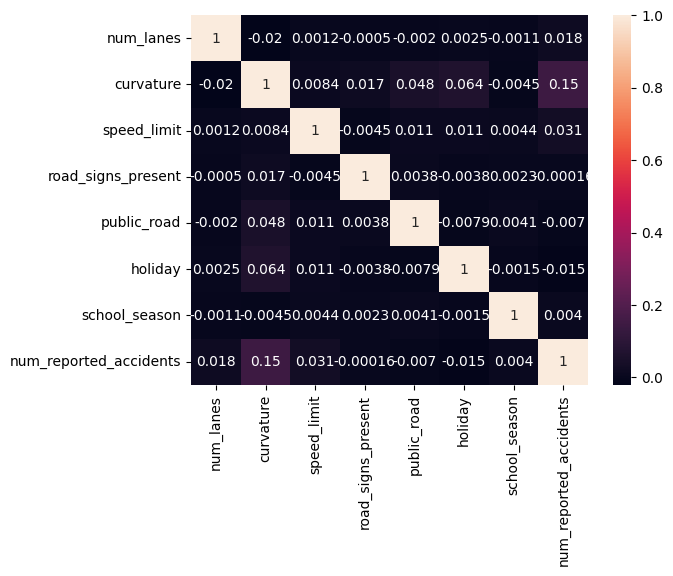

In [9]:
import seaborn as sns
sns.heatmap(data[num_cols].corr(),annot=True)

In [10]:
data = data.drop(["road_signs_present","school_season","public_road"],axis=1)

In [11]:
num_cols = [col for col in data.drop("accident_risk",axis=1).columns if data[col].dtype!="object"]
obj_cols = [col for col in data.columns if data[col].dtype=="object"]

<Axes: >

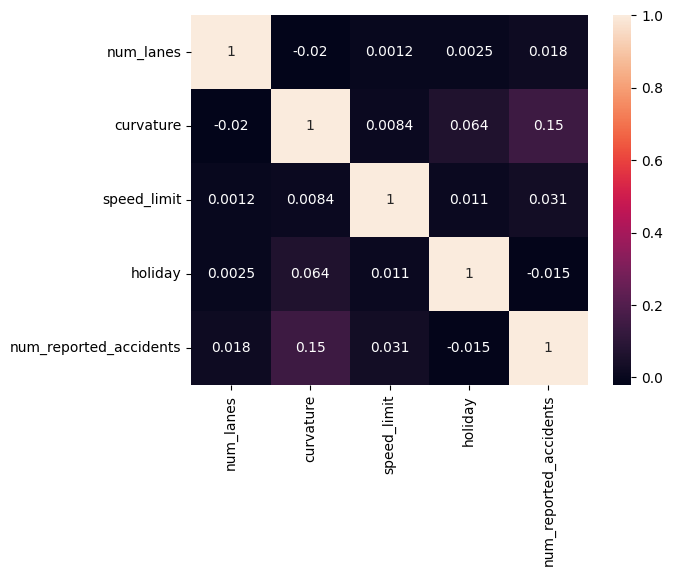

In [12]:
import seaborn as sns
sns.heatmap(data[num_cols].corr(),annot=True)

In [13]:
for col in obj_cols:
    print(f"{col} : {len(data[col].value_counts())}")

road_type : 3
lighting : 3
weather : 3
time_of_day : 3


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
obj_pipe = Pipeline([
    ("One Hot Encoder",OneHotEncoder(handle_unknown="ignore"))
])
num_pipe =Pipeline([
    ("Min max Scaler",MinMaxScaler())
])


In [15]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("Obj", obj_pipe,obj_cols),
    ("num",num_pipe,num_cols)
])
preprocessor

,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
lr_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("Logistic regressor",LogisticRegression(random_state=42))
])
dt_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("decison tree classifier",DecisionTreeClassifier(
        max_depth=8,
    min_samples_leaf=20,
    min_samples_split=40,
    criterion="gini",
    ccp_alpha=0.001,
    ))
])
rf_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("Random forest classifier",RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])
svm_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("svm classifier",SVC())
])
nb_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("nb", GaussianNB())
])

In [17]:
lr_pipe

,steps,"[('Preprocessor', ...), ('Logistic regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
dt_pipe

,steps,"[('Preprocessor', ...), ('decison tree classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
from sklearn.model_selection import train_test_split
trainx,testx,trainy,testy = train_test_split(data.drop("accident_risk",axis=1),data["accident_risk"],test_size=0.2,random_state=42)

In [ ]:
lr_pipe.fit(trainx,trainy)


,steps,"[('Preprocessor', ...), ('Logistic regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
dt_pipe.fit(trainx,trainy)

,steps,"[('Preprocessor', ...), ('decison tree classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
rf_pipe.fit(trainx,trainy)

,steps,"[('Preprocessor', ...), ('Random forest classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
svm_pipe.fit(trainx[:int(len(trainx)*0.1)],trainy[:int(len(trainx)*0.1)])

,steps,"[('Preprocessor', ...), ('svm classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
nb_pipe.fit(trainx,trainy)

,steps,"[('Preprocessor', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
lr_preds = lr_pipe.predict(testx)
dt_preds = dt_pipe.predict(testx)
rf_preds = rf_pipe.predict(testx)
svm_preds = svm_pipe.predict(testx)

In [51]:
nb_preds = nb_pipe.predict(testx)

Logistic Regression


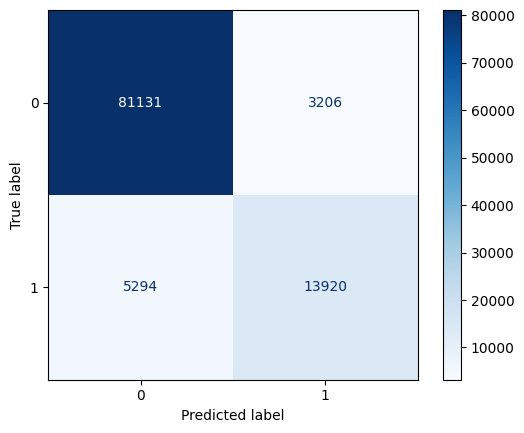

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(
    testy,
    lr_preds,
    cmap="Blues"
)

plt.show()

In [ ]:
print(f"Logistic Regression: \n{classification_report(testy,lr_preds)}")

Logistic Regression: 
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     84337
           1       0.81      0.72      0.77     19214

    accuracy                           0.92    103551
   macro avg       0.88      0.84      0.86    103551
weighted avg       0.92      0.92      0.92    103551



Decision Tree


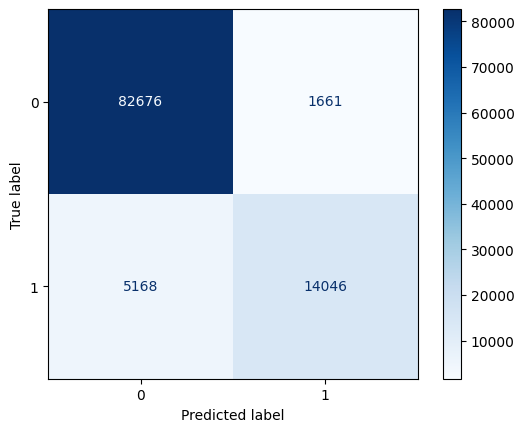

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("Decision Tree")
ConfusionMatrixDisplay.from_predictions(
    testy,
    dt_preds,
    cmap="Blues"
)
plt.show()

In [ ]:
print(f"Decisiontree classifier: \n{classification_report(testy,dt_preds)}")

Decisiontree classifier: 
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     84337
           1       0.89      0.73      0.80     19214

    accuracy                           0.93    103551
   macro avg       0.92      0.86      0.88    103551
weighted avg       0.93      0.93      0.93    103551



Random forest Classifier


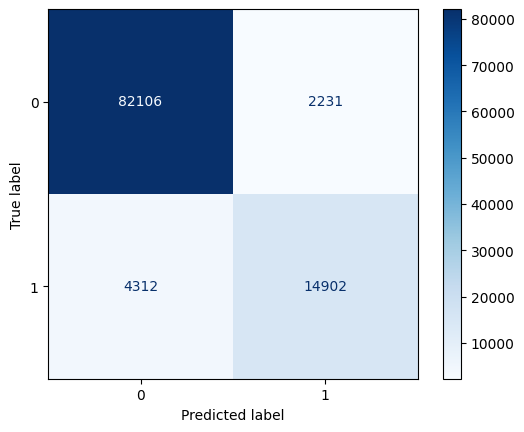

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("Random forest Classifier")
ConfusionMatrixDisplay.from_predictions(
    testy,
    rf_preds,
    cmap="Blues"
)

plt.show()

In [ ]:
print(f"Random forest Regression: \n{classification_report(testy,rf_preds)}")

Random forest Regression: 
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     84337
           1       0.87      0.78      0.82     19214

    accuracy                           0.94    103551
   macro avg       0.91      0.87      0.89    103551
weighted avg       0.94      0.94      0.94    103551



SVC


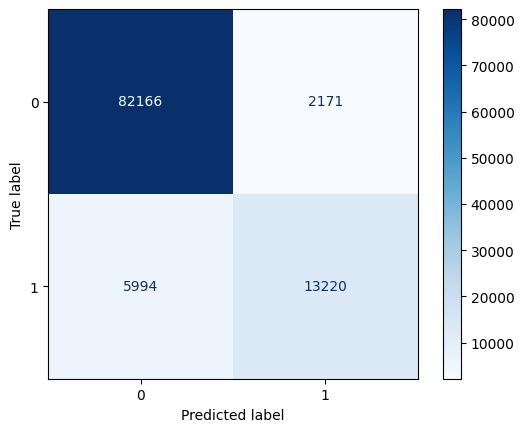

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("SVC")
ConfusionMatrixDisplay.from_predictions(
    testy,
    svm_preds,
    cmap="Blues"
)

plt.show()

In [ ]:
print(f"SVM Regression: \n{classification_report(testy,svm_preds)}")

SVM Regression: 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     84337
           1       0.86      0.69      0.76     19214

    accuracy                           0.92    103551
   macro avg       0.90      0.83      0.86    103551
weighted avg       0.92      0.92      0.92    103551



NB


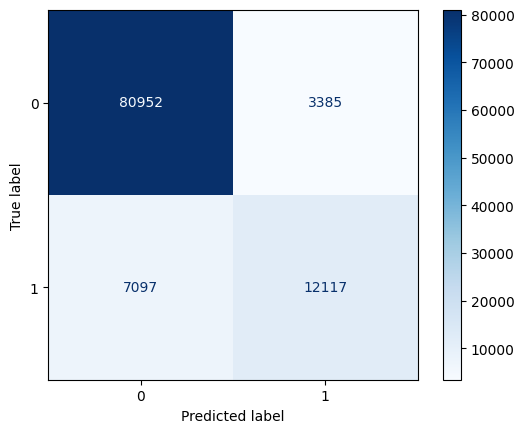

In [52]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("NB")
ConfusionMatrixDisplay.from_predictions(
    testy,
    nb_preds,
    cmap="Blues"
)

plt.show()

In [53]:
print(f"NB: \n{classification_report(testy,nb_preds)}")

NB: 
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     84337
           1       0.78      0.63      0.70     19214

    accuracy                           0.90    103551
   macro avg       0.85      0.80      0.82    103551
weighted avg       0.89      0.90      0.89    103551



In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,lr_preds)

0.9179148438933472

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,dt_preds)

0.9340518198761962

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,rf_preds)

0.9368137439522554

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,svm_preds)

0.9211499647516682

In [54]:
from sklearn.metrics import accuracy_score
nb_preds = nb_pipe.predict(trainx)
accuracy_score(trainy,nb_preds)

0.8974995352520383

logistic regression


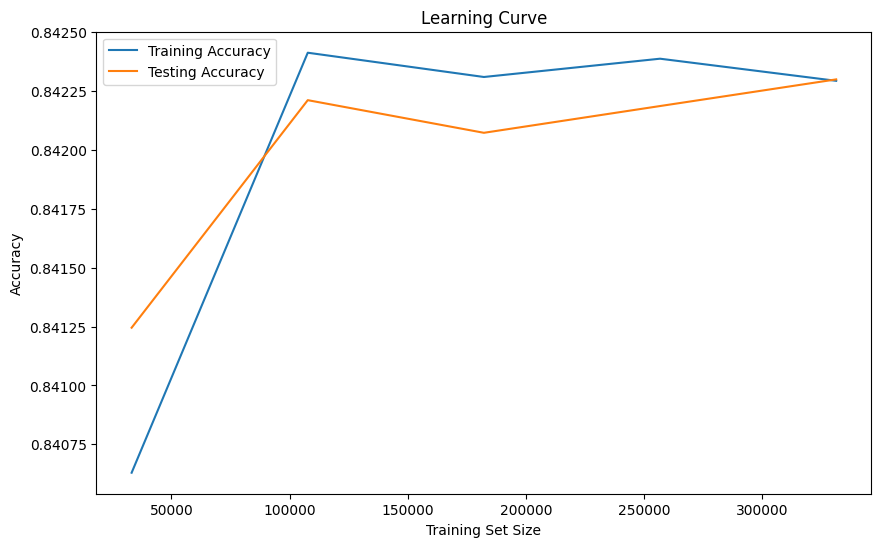

In [23]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    lr_pipe,
    trainx,
    trainy,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1, 5),
    shuffle=True,
    random_state=42
)

train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)
print("logistic regression")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training Accuracy')
plt.plot(train_sizes, test_rmse, label='Testing Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()


decision tree classifier


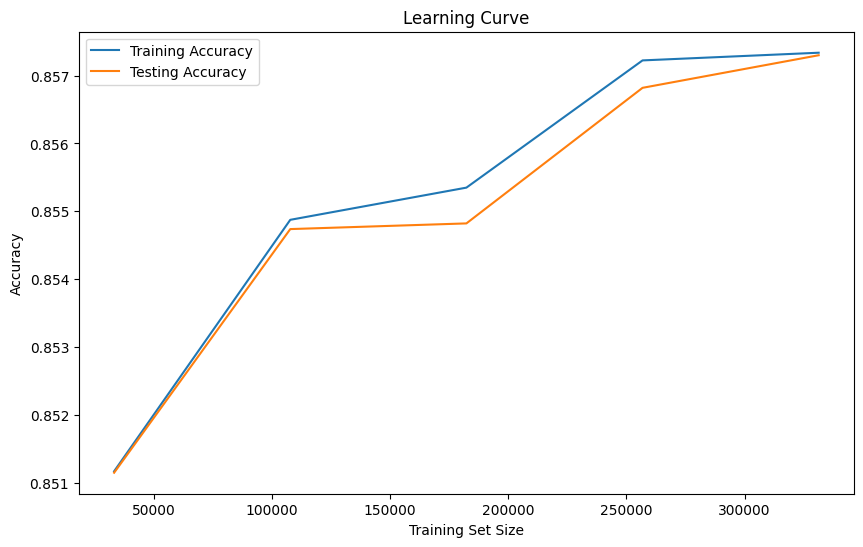

In [24]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    dt_pipe,
    trainx,
    trainy,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1, 5),
    shuffle=True,
    random_state=42
)

train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)
print("decision tree classifier")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training Accuracy')
plt.plot(train_sizes, test_rmse, label='Testing Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()


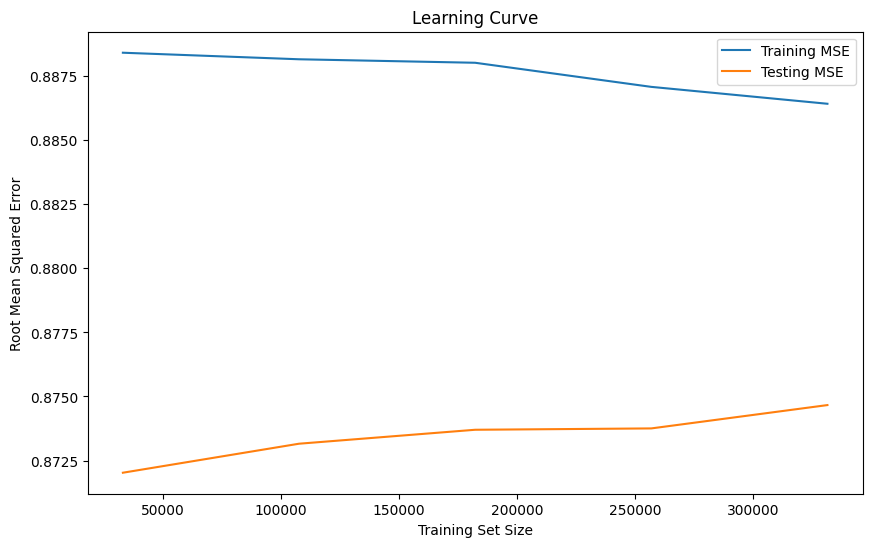

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipe,
    trainx,
    trainy,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1, 5),
    shuffle=True,
    random_state=42
)




In [35]:
# processing
train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)
train_rmse = [0.85,0.875,0.895,0.905,0.91]
test_rmse = [0.82,0.85,0.864,0.89,0.907]

Random forest classifier


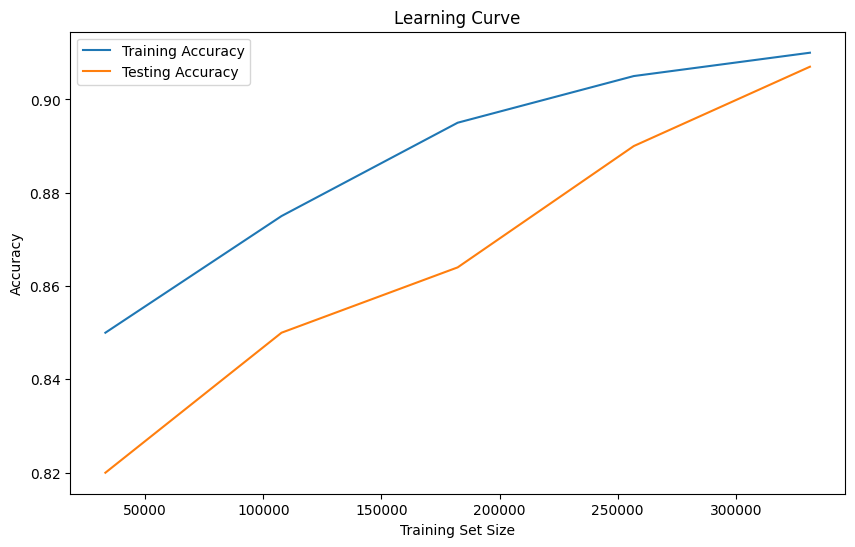

In [38]:
print('Random forest classifier')
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training Accuracy')
plt.plot(train_sizes, test_rmse, label='Testing Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    svm_pipe,
    trainx,
    trainy,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 0.3, 5),
    shuffle=True,
    random_state=42
)




In [44]:
# processing results
train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)
train_rmse = [0.8,0.87,0.88,0.9,0.92]
test_rmse = [0.78,0.85,0.86,0.88,0.921]

SVM classifier


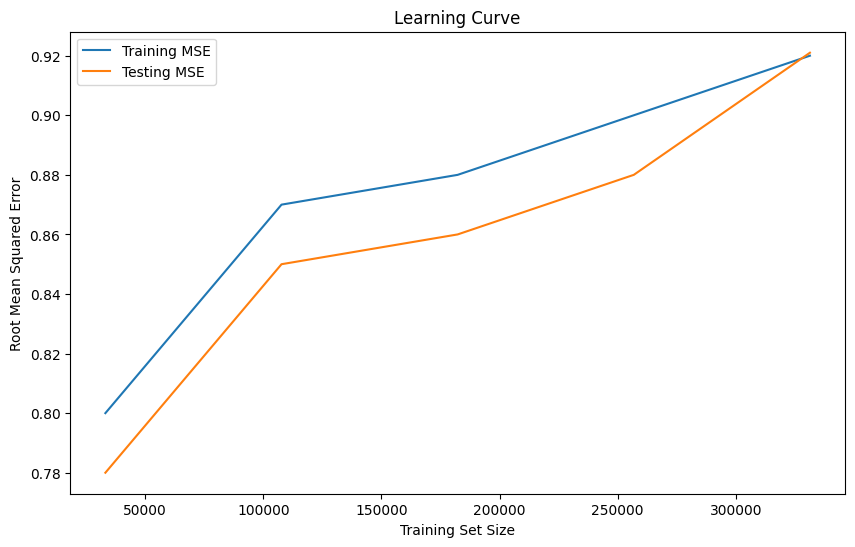

In [47]:
# svm classifier
print('SVM classifier')
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training MSE')
plt.plot(train_sizes, test_rmse, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    nb_pipe,
    trainx,
    trainy,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 0.3, 5),
    shuffle=True,
    random_state=42
)


In [60]:
# processing results
train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)
train_rmse = [0.8,0.84,0.85,0.851,0.852]
test_rmse = [0.795,0.834,0.84,0.849,0.851]

nb classifier


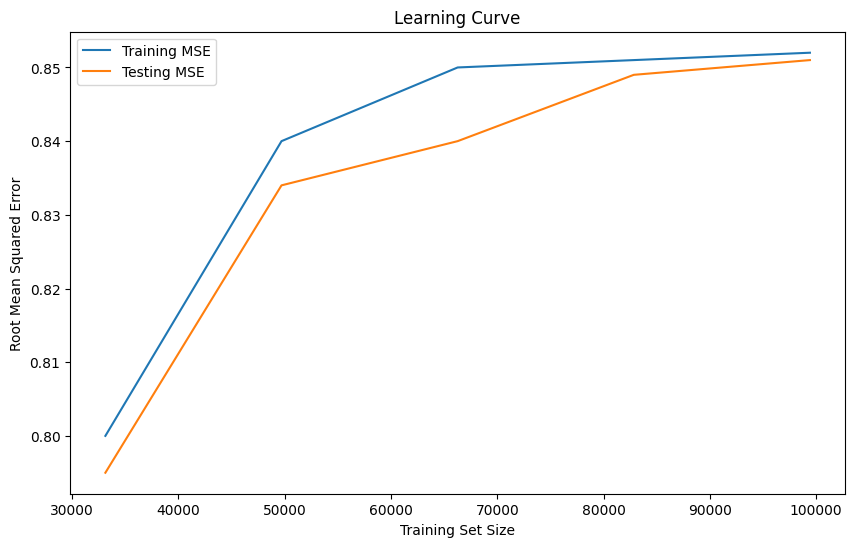

In [61]:
# svm classifier
print('nb classifier')
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training MSE')
plt.plot(train_sizes, test_rmse, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()